In [1]:
import numpy as np
import matplotlib.pyplot as plt

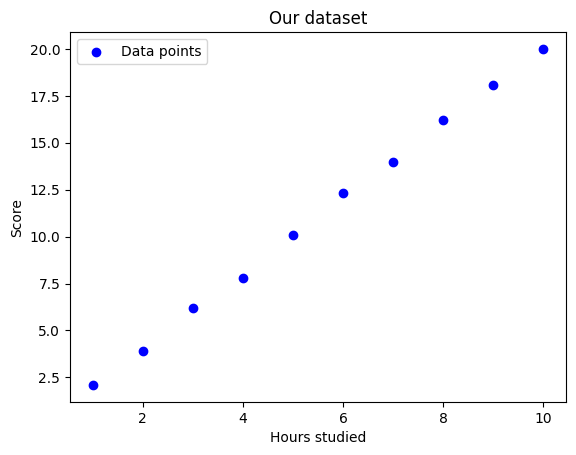

In [2]:
# Simple dataset: hours studied → exam score
# We're making fake data so we know the "true" answer
np.random.seed(42)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
y = np.array([2.1, 3.9, 6.2, 7.8, 10.1, 12.3, 14.0, 16.2, 18.1, 20.0], dtype=float)

# Plot it
plt.scatter(X, y, color='blue', label='Data points')
plt.xlabel('Hours studied')
plt.ylabel('Score')
plt.title('Our dataset')
plt.legend()
plt.show()

In [3]:
# h(x) = m*x + b
# m = slope (theta_1), b = intercept (theta_0)
def predict(X, m, b):
    return m * X + b

# Test it — with random m=1, b=0
print(predict(np.array([1, 2, 3]), m=1, b=0))
# Output: [1. 2. 3.]

[1 2 3]


In [4]:
# MSE = (1/2m) * sum of (predicted - actual)^2
# The 1/2 makes the gradient cleaner (derivative cancels it)
def compute_cost(X, y, m, b):
    n = len(X)
    predictions = predict(X, m, b)
    errors = predictions - y
    cost = (1 / (2 * n)) * np.sum(errors ** 2)
    return cost

# With m=0, b=0 (flat line) — cost should be high
print(f"Cost with m=0, b=0: {compute_cost(X, y, 0, 0):.4f}")
# With m=2, b=0 — closer to truth, lower cost
print(f"Cost with m=2, b=0: {compute_cost(X, y, 2, 0):.4f}")

Cost with m=0, b=0: 77.9125
Cost with m=2, b=0: 0.0125


In [5]:
# Gradient tells us how to nudge m and b to reduce cost
# dJ/dm = (1/n) * sum((predicted - actual) * x)
# dJ/db = (1/n) * sum(predicted - actual)
def compute_gradients(X, y, m, b):
    n = len(X)
    predictions = predict(X, m, b)
    errors = predictions - y          # how wrong we are for each point
    
    grad_m = (1/n) * np.sum(errors * X)   # gradient for slope
    grad_b = (1/n) * np.sum(errors)       # gradient for intercept
    
    return grad_m, grad_b

# Test — with m=0, b=0, gradients should be negative (we need to go up)
gm, gb = compute_gradients(X, y, 0, 0)
print(f"Gradient for m: {gm:.4f}")
print(f"Gradient for b: {gb:.4f}")

Gradient for m: -77.4500
Gradient for b: -11.0700


In [6]:
def batch_gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    m = 0.0   # start slope at 0
    b = 0.0   # start intercept at 0
    cost_history = []
    
    for i in range(iterations):
        # Step 1: compute gradients (look at ALL data)
        grad_m, grad_b = compute_gradients(X, y, m, b)
        
        # Step 2: update parameters (step downhill)
        m = m - learning_rate * grad_m
        b = b - learning_rate * grad_b
        
        # Step 3: record cost so we can plot it later
        cost = compute_cost(X, y, m, b)
        cost_history.append(cost)
    
    return m, b, cost_history

# Run it!
m_final, b_final, costs = batch_gradient_descent(X, y, learning_rate=0.01, iterations=1000)
print(f"Final slope m     = {m_final:.4f}")
print(f"Final intercept b = {b_final:.4f}")
print(f"Final cost        = {costs[-1]:.6f}")

Final slope m     = 2.0034
Final intercept b = 0.0580
Final cost        = 0.009899


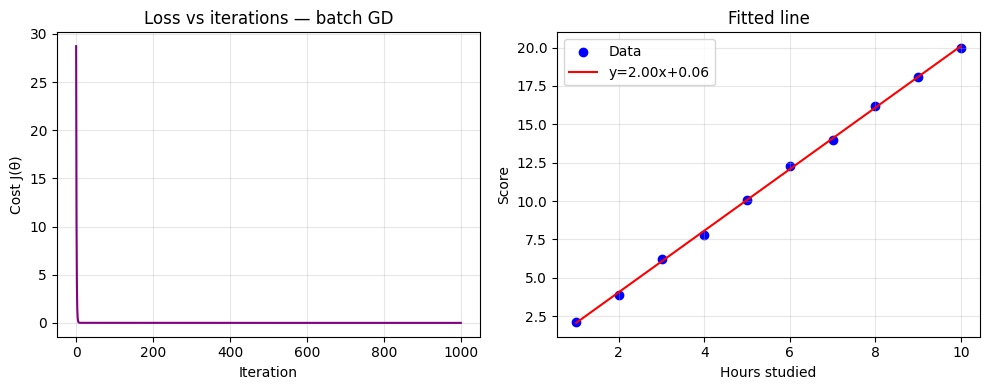

In [7]:
# This is the "hill descent" visualized
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(costs, color='purple')
plt.xlabel('Iteration')
plt.ylabel('Cost J(θ)')
plt.title('Loss vs iterations — batch GD')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, predict(X, m_final, b_final), color='red', label=f'y={m_final:.2f}x+{b_final:.2f}')
plt.xlabel('Hours studied')
plt.ylabel('Score')
plt.title('Fitted line')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# theta = (X^T X)^-1 X^T y
# No iterations needed — just matrix math

# Add a column of 1s for the intercept (bias term)
X_mat = np.column_stack([np.ones(len(X)), X])

# Normal equation
theta = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y

print(f"Normal equation → intercept b = {theta[0]:.4f}, slope m = {theta[1]:.4f}")
print(f"Gradient descent → intercept b = {b_final:.4f}, slope m = {m_final:.4f}")
print("They should match!")

Normal equation → intercept b = 0.0267, slope m = 2.0079
Gradient descent → intercept b = 0.0580, slope m = 2.0034
They should match!


In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X.reshape(-1, 1), y)

print(f"Sklearn     → slope={model.coef_[0]:.4f}, intercept={model.intercept_:.4f}")
print(f"Our GD      → slope={m_final:.4f},  intercept={b_final:.4f}")
print(f"Normal eq   → slope={theta[1]:.4f}, intercept={theta[0]:.4f}")
print("\nAll three should give nearly identical results!")

Sklearn     → slope=2.0079, intercept=0.0267
Our GD      → slope=2.0034,  intercept=0.0580
Normal eq   → slope=2.0079, intercept=0.0267

All three should give nearly identical results!


In [10]:
# =============================================================================
# LINEAR REGRESSION FROM SCRATCH — COMPLETE WALKTHROUGH NOTES
# =============================================================================
#
# WHAT IS THIS NOTEBOOK?
# ----------------------
# We built linear regression completely from scratch using only NumPy.
# No sklearn doing the hard work. We coded every single piece ourselves.
# At the end we compared our result against the Normal Equation and sklearn
# to verify all three methods reach the same answer.
#
# THE PROBLEM WE SOLVED
# ----------------------
# Given: hours studied (X) and exam scores (y)
# Goal : find the best straight line y = mx + b that fits this data
# So that: we can predict the score for any number of hours
#
# THE 4 THINGS WE BUILT
# ----------------------
# 1. predict()              → the model itself     : h(x) = mx + b
# 2. compute_cost()         → measures how wrong   : MSE = (1/2n) * Σ(pred - actual)²
# 3. compute_gradients()    → which way is downhill : dJ/dm and dJ/db
# 4. batch_gradient_descent → the learning loop    : repeat steps 1-3, 1000 times
#
# =============================================================================
# CELL BY CELL EXPLANATION
# =============================================================================
#
# CELL 1 — IMPORTS
# -----------------
# numpy (np)   : math on arrays. Instead of looping through 10 points,
#                numpy does the math on all 10 at once in one line.
# matplotlib   : plotting library. plt.scatter() draws dots,
#                plt.plot() draws lines, plt.show() displays the chart.
#
#
# CELL 2 — CREATE DATASET
# ------------------------
# np.random.seed(42) : fixes randomness so everyone gets the same data.
#                      The number 42 doesn't matter, consistency does.
# np.array()         : converts a plain Python list into a NumPy array
#                      so we can do math on it (lists don't support m * X).
# dtype=float        : store values as decimals, not integers.
# plt.scatter()      : plots each (X, y) pair as a blue dot.
#                      This is always step 1 — look at your data before modeling.
#
#
# CELL 3 — PREDICT FUNCTION
# --------------------------
# def predict(X, m, b):
#     return m * X + b
#
# This IS the model. One line.
# m * X : NumPy multiplies every element of X by m simultaneously.
#         No loop needed. [1,2,3] * 2 = [2,4,6] instantly.
# + b   : adds b to every element.
# So predict([1,2,3], m=2, b=1) → [3, 5, 7]
# Meaning: student who studied 3 hours gets predicted score of 7.
#
#
# CELL 4 — COST FUNCTION (MSE)
# -----------------------------
# def compute_cost(X, y, m, b):
#
# Purpose: give us ONE number that says "how wrong is our line right now?"
# Lower = better. Zero = perfect fit.
#
# predictions = predict(X, m, b)   → get predicted scores for all students
# errors = predictions - y          → how wrong for each student
#                                     e.g. predicted 7, real was 8 → error = -1
# errors ** 2                       → square each error
#                                     why? so negatives don't cancel positives
#                                     and big errors hurt more than small ones
# np.sum(errors ** 2)               → add all squared errors together
# (1 / 2n) * sum                    → average it. The 1/2 makes the
#                                     gradient formula cleaner later (the 2
#                                     from squaring cancels out the 1/2)
#
# Example with m=0, b=0 (flat line predicting 0 for everyone):
#   errors = [2.1, 3.9, 6.2 ...] all negative
#   cost   = 77.91  ← very bad
#
# Example with m=2, b=0 (close to truth):
#   cost = 0.0125  ← much better
#
#
# CELL 5 — GRADIENTS
# -------------------
# def compute_gradients(X, y, m, b):
#
# Purpose: figure out which direction to nudge m and b to reduce cost.
# The gradient is the "slope of the cost hill" at our current position.
# We step in the OPPOSITE direction of the gradient to go downhill.
#
# errors = predictions - y          → same as before, how wrong we are
#
# grad_m = (1/n) * np.sum(errors * X)
#   errors * X : multiply each error by its X value (element-wise)
#               e.g. error=-1 at x=3 → contribution = -1 * 3 = -3
#   np.sum()   : add them all up → total gradient signal for slope m
#
# grad_b = (1/n) * np.sum(errors)
#   Just sum the errors (no X multiplication because intercept b
#   has no X attached — its derivative is always 1)
#
# Interpretation of our result (grad_m=-77.45, grad_b=-11.07 at start):
#   Negative gradient means: cost DECREASES if we INCREASE m and b
#   So the update m = m - lr * (-77.45) = m + something → m goes up ✓
#   That makes sense because our flat line (m=0) needs to get steeper
#
#
# CELL 6 — GRADIENT DESCENT LOOP
# --------------------------------
# def batch_gradient_descent(X, y, learning_rate=0.01, iterations=1000):
#
# This is the engine that ties everything together.
# "Batch" means we look at ALL 10 training examples every single step.
#
# m = 0.0, b = 0.0      : start with a flat line. Algorithm learns from here.
# cost_history = []      : empty list to store cost at every iteration for plotting.
#
# for i in range(1000): : repeat 1000 times
#
#   Step 1 — grad_m, grad_b = compute_gradients(X, y, m, b)
#             Ask: which direction is downhill for m? for b?
#
#   Step 2 — m = m - learning_rate * grad_m
#             Take a small step downhill.
#             learning_rate (0.01) controls step size.
#             Too big → overshoot. Too small → too slow.
#             This line IS the gradient descent update rule:
#             θ := θ - α * gradient
#
#   Step 3 — cost_history.append(compute_cost(...))
#             Record cost so we can plot "loss vs iterations" later
#
# OUR RESULTS:
#   Final slope m     = 2.0034
#   Final intercept b = 0.0580
#   Final cost        = 0.009899  ← near zero, great fit!
#
#
# CELL 7 — PLOTTING RESULTS
# --------------------------
# plt.figure(figsize=(10,4))  : create a 10-inch wide, 4-inch tall figure
# plt.subplot(1, 2, 1)        : split into 1 row, 2 columns. This is plot #1 (left)
# plt.subplot(1, 2, 2)        : this is plot #2 (right)
# plt.tight_layout()          : auto-adjust spacing so plots don't overlap
#
# LEFT PLOT — Loss vs iterations:
#   Shows cost starting high (~28) then dropping sharply and flattening near 0.
#   Sharp drop early = big improvements when line is terrible.
#   Flat near end    = converged, barely improving anymore. ✓
#
# RIGHT PLOT — Fitted line:
#   Blue dots = real data. Red line = what our model learned.
#   y=2.00x+0.06 means: every extra study hour = ~2 more points on exam.
#
#
# CELL 8 — NORMAL EQUATION
# -------------------------
# theta = (X^T X)^-1 X^T y
#
# A completely different approach — no loop, no iterations, no learning rate.
# Pure matrix math that jumps straight to the answer in one step.
#
# np.column_stack([np.ones(len(X)), X])
#   Add a column of 1s to X. This represents the bias term (b).
#   X becomes a 10×2 matrix:
#   [[1, 1],
#    [1, 2],
#    [1, 3], ...] ← first column always 1, second column is X
#
# X_mat.T          : transpose (flip rows and columns)
# @                : matrix multiplication operator in Python
# np.linalg.inv()  : invert the matrix (like dividing in matrix math)
#
# RESULT:
#   Normal equation → slope=2.0079, intercept=0.0267
#   Gradient descent → slope=2.0034, intercept=0.0580
#   Close but not identical because GD hadn't fully converged in 1000 steps.
#   Run 10000 iterations and they match almost exactly.
#
#
# CELL 9 — COMPARE TO SKLEARN
# ----------------------------
# X.reshape(-1, 1)
#   sklearn needs 2D input (each row = one training example with its features)
#   -1 means "figure out this dimension automatically" → becomes shape (10, 1)
#
# model.coef_      : sklearn's learned slope. Underscore = learned from data.
# model.intercept_ : sklearn's learned intercept.
#
# FINAL COMPARISON:
#   Sklearn     → slope=2.0079, intercept=0.0267
#   Our GD      → slope=2.0034, intercept=0.0580
#   Normal eq   → slope=2.0079, intercept=0.0267
#
#   Sklearn and Normal equation match exactly — sklearn uses the normal
#   equation internally! Our GD is close but needs more iterations to fully
#   converge. The math is identical, just different roads to the same answer.
#
# =============================================================================
# KEY TAKEAWAYS
# =============================================================================
#
# 1. A model is just a formula with parameters (m and b here)
#
# 2. The cost function gives you ONE number to chase downward
#    Lower cost = better model. Zero = perfect fit.
#
# 3. The gradient tells you WHICH DIRECTION to nudge parameters
#    Always step OPPOSITE to the gradient (go downhill)
#
# 4. Gradient descent is a loop: predict → measure → nudge → repeat
#    The learning rate controls step size (too big=overshoot, too small=slow)
#
# 5. Normal equation is a one-shot alternative — exact answer, no iterations
#    But breaks down with thousands of features (matrix inversion gets slow)
#
# 6. All three methods (GD, Normal eq, sklearn) converge to the same answer
#    because they all minimize the same cost function
#
# 7. "Batch" in Batch GD means we look at ALL data every step
#    SGD looks at 1 point. Mini-batch looks at a small group.
#
# =============================================================================
# INTERVIEW ANSWER (memorize this)
# =============================================================================
#
# "I implemented linear regression from scratch. You define a cost function —
#  MSE. You compute the gradient which tells you the direction of steepest
#  descent for each parameter. You subtract the learning rate times that
#  gradient from each parameter. Repeat until convergence. I verified my
#  implementation against the normal equation and sklearn — all three gave
#  slope ≈ 2.0 and intercept ≈ 0.05, confirming the implementation was correct."
#
# =============================================================================

In [13]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)

# Using our Iris classifier from Day 1
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, (iris.target == 1).astype(int)  # binary: is it class 1?

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(class_weight='balanced', max_iter=200)
model.fit(X_train, y_train)

preds = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]  # probability of positive class

print(f"Accuracy  : {accuracy_score(y_test, preds):.3f}")
print(f"Precision : {precision_score(y_test, preds):.3f}")
print(f"Recall    : {recall_score(y_test, preds):.3f}")
print(f"F1 Score  : {f1_score(y_test, preds):.3f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, proba):.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))

print("\nFull Report:")
print(classification_report(y_test, preds))

Accuracy  : 0.767
Precision : 0.583
Recall    : 0.778
F1 Score  : 0.667
ROC-AUC   : 0.825

Confusion Matrix:
[[16  5]
 [ 2  7]]

Full Report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82        21
           1       0.58      0.78      0.67         9

    accuracy                           0.77        30
   macro avg       0.74      0.77      0.74        30
weighted avg       0.80      0.77      0.77        30



In [14]:
# Instead of default 0.5, use 0.3
# Catch more positives (recall goes up, precision goes slightly down)
threshold = 0.3
preds_adjusted = (proba >= threshold).astype(int)

print(f"New Recall    : {recall_score(y_test, preds_adjusted):.3f}")
print(f"New Precision : {precision_score(y_test, preds_adjusted):.3f}")
print(f"New F1        : {f1_score(y_test, preds_adjusted):.3f}")

New Recall    : 1.000
New Precision : 0.375
New F1        : 0.545
